<a href="https://colab.research.google.com/github/samaneh-m/TU-simulation-base-inference/blob/main/Group19_SBI_FinalModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install "bayesflow>=2.0"
!pip install tensorflow hmmlearn

INFO:bayesflow:Using backend 'tensorflow'
INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - loss: 36.4398 - val_loss: 21.0555
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: -5.5966 - val_loss: -0.5773
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: -13.4695 - val_loss: -12.6413
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: -17.7370 - val_loss: -17.0447
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: -20.9914 - val_loss: -22.2364
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: -23.5492 - val_loss: -26.0548
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: -25.8751 - val_loss: -29.1910
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: -27.6961 - val_loss: -32.6937
Epoch 9/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: -29.4996 - val_loss: -34.8302
Epoch 10/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: -30.9590 - val_loss: -36.6977
Epoch 11/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: -32.1651 - val_loss: -38.7837

       hidden_states_0  hidden_states_1  hidden_states_2  hidden_states_3  \
count         3.000000         3.000000         3.000000         3.000000   
mean          0.116700         0.170860         0.216169         0.240118   
std           0.176786         0.130343         0.170953         0.214020   
min           0.000000         0.022544         0.045439         0.053684   
25%           0.015000         0.122701         0.130582         0.123266   
50%           0.030000         0.222857         0.215726         0.192848   
75%           0.175049         0.245017         0.301534         0.333335   
max           0.320099         0.267178         0.387343         0.473822   

       hidden_states_4  hidden_states_5  hidden_states_6  hidden_states_7  \
count         3.000000         3.000000         3.000000         3.000000   
mean          0.256978         0.288626         0.312522         0.334530   
std           0.251443         0.284872         0.316943         0.350905  

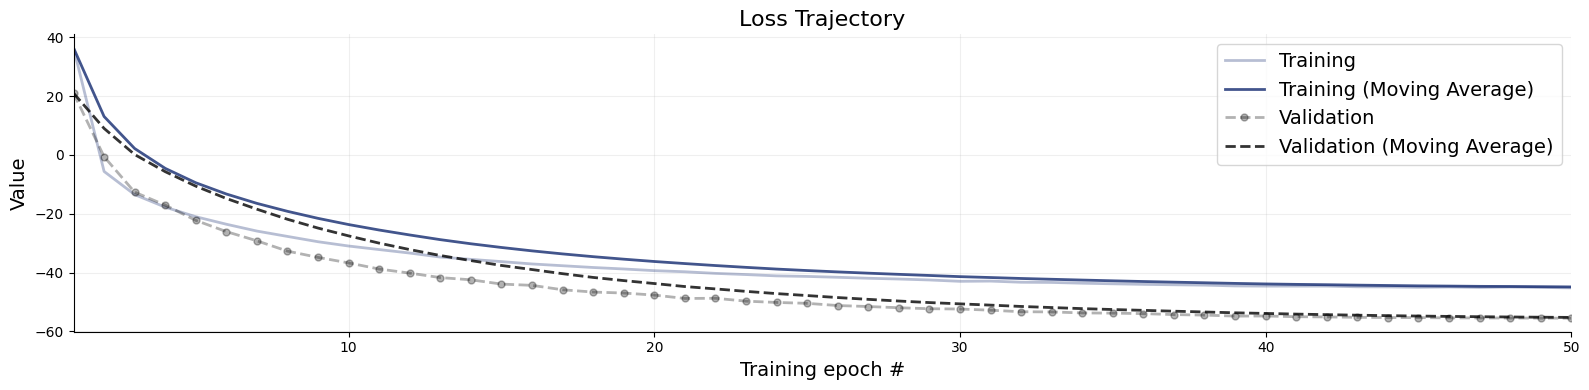

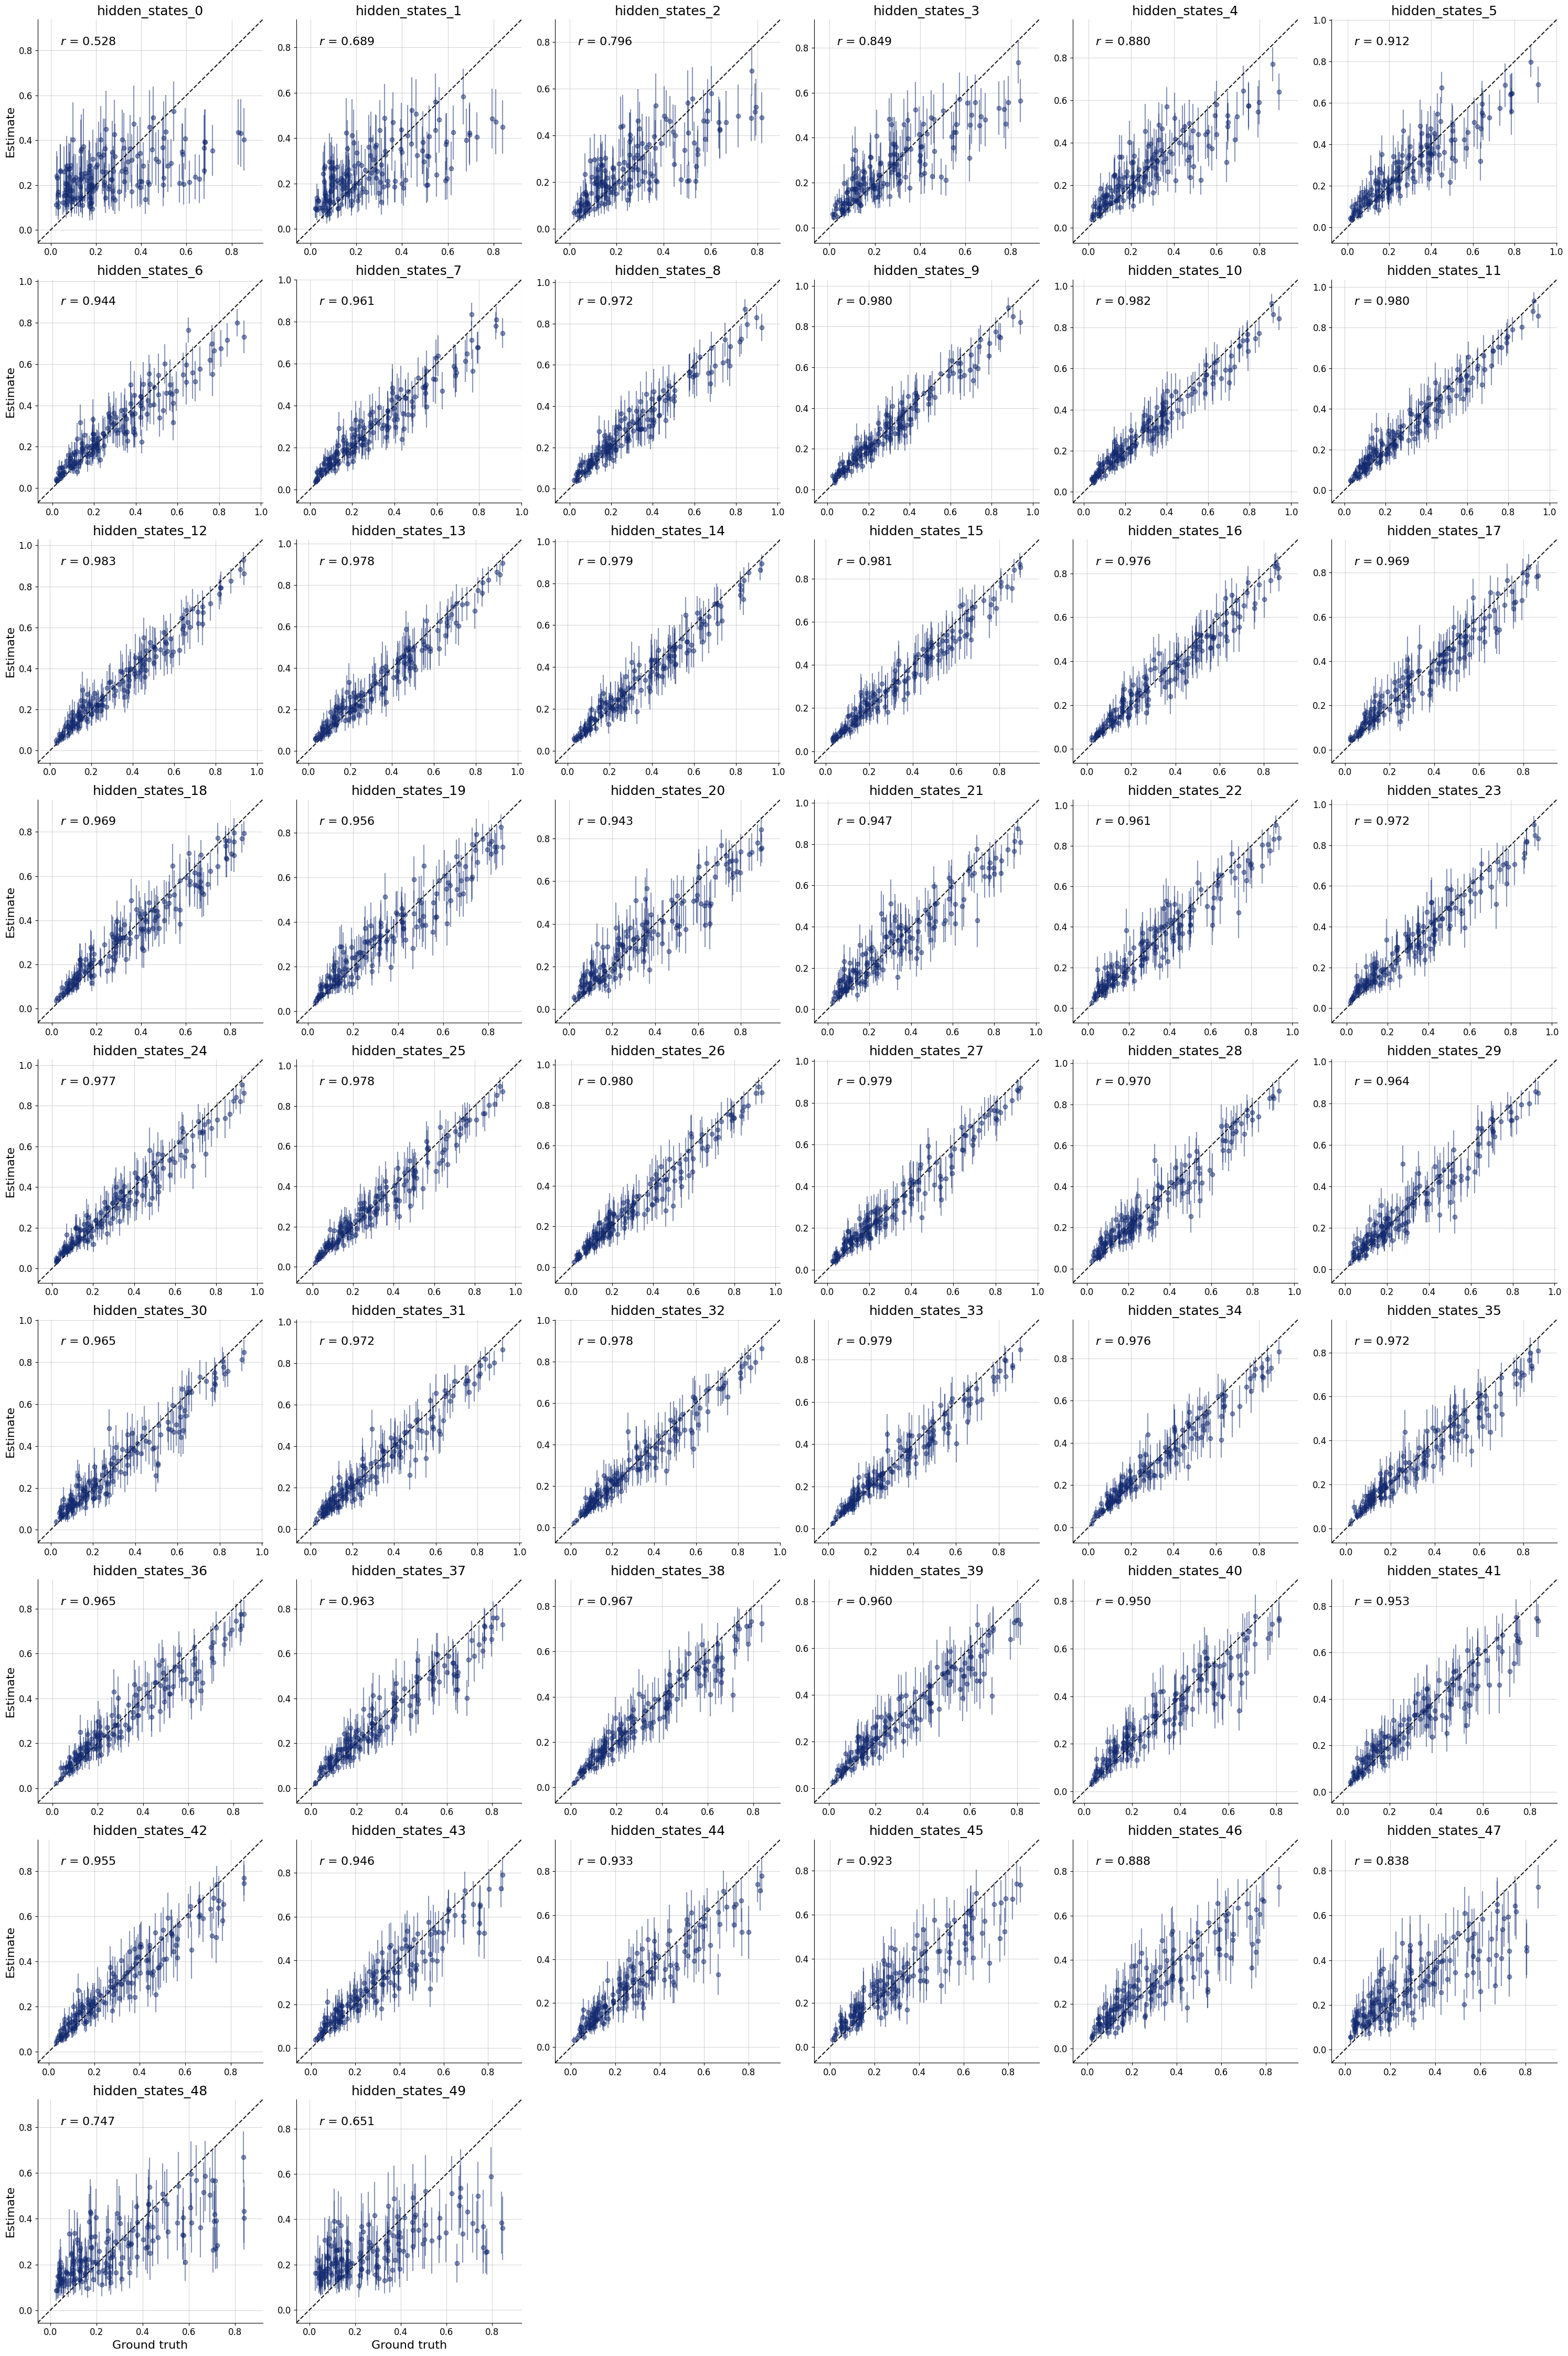

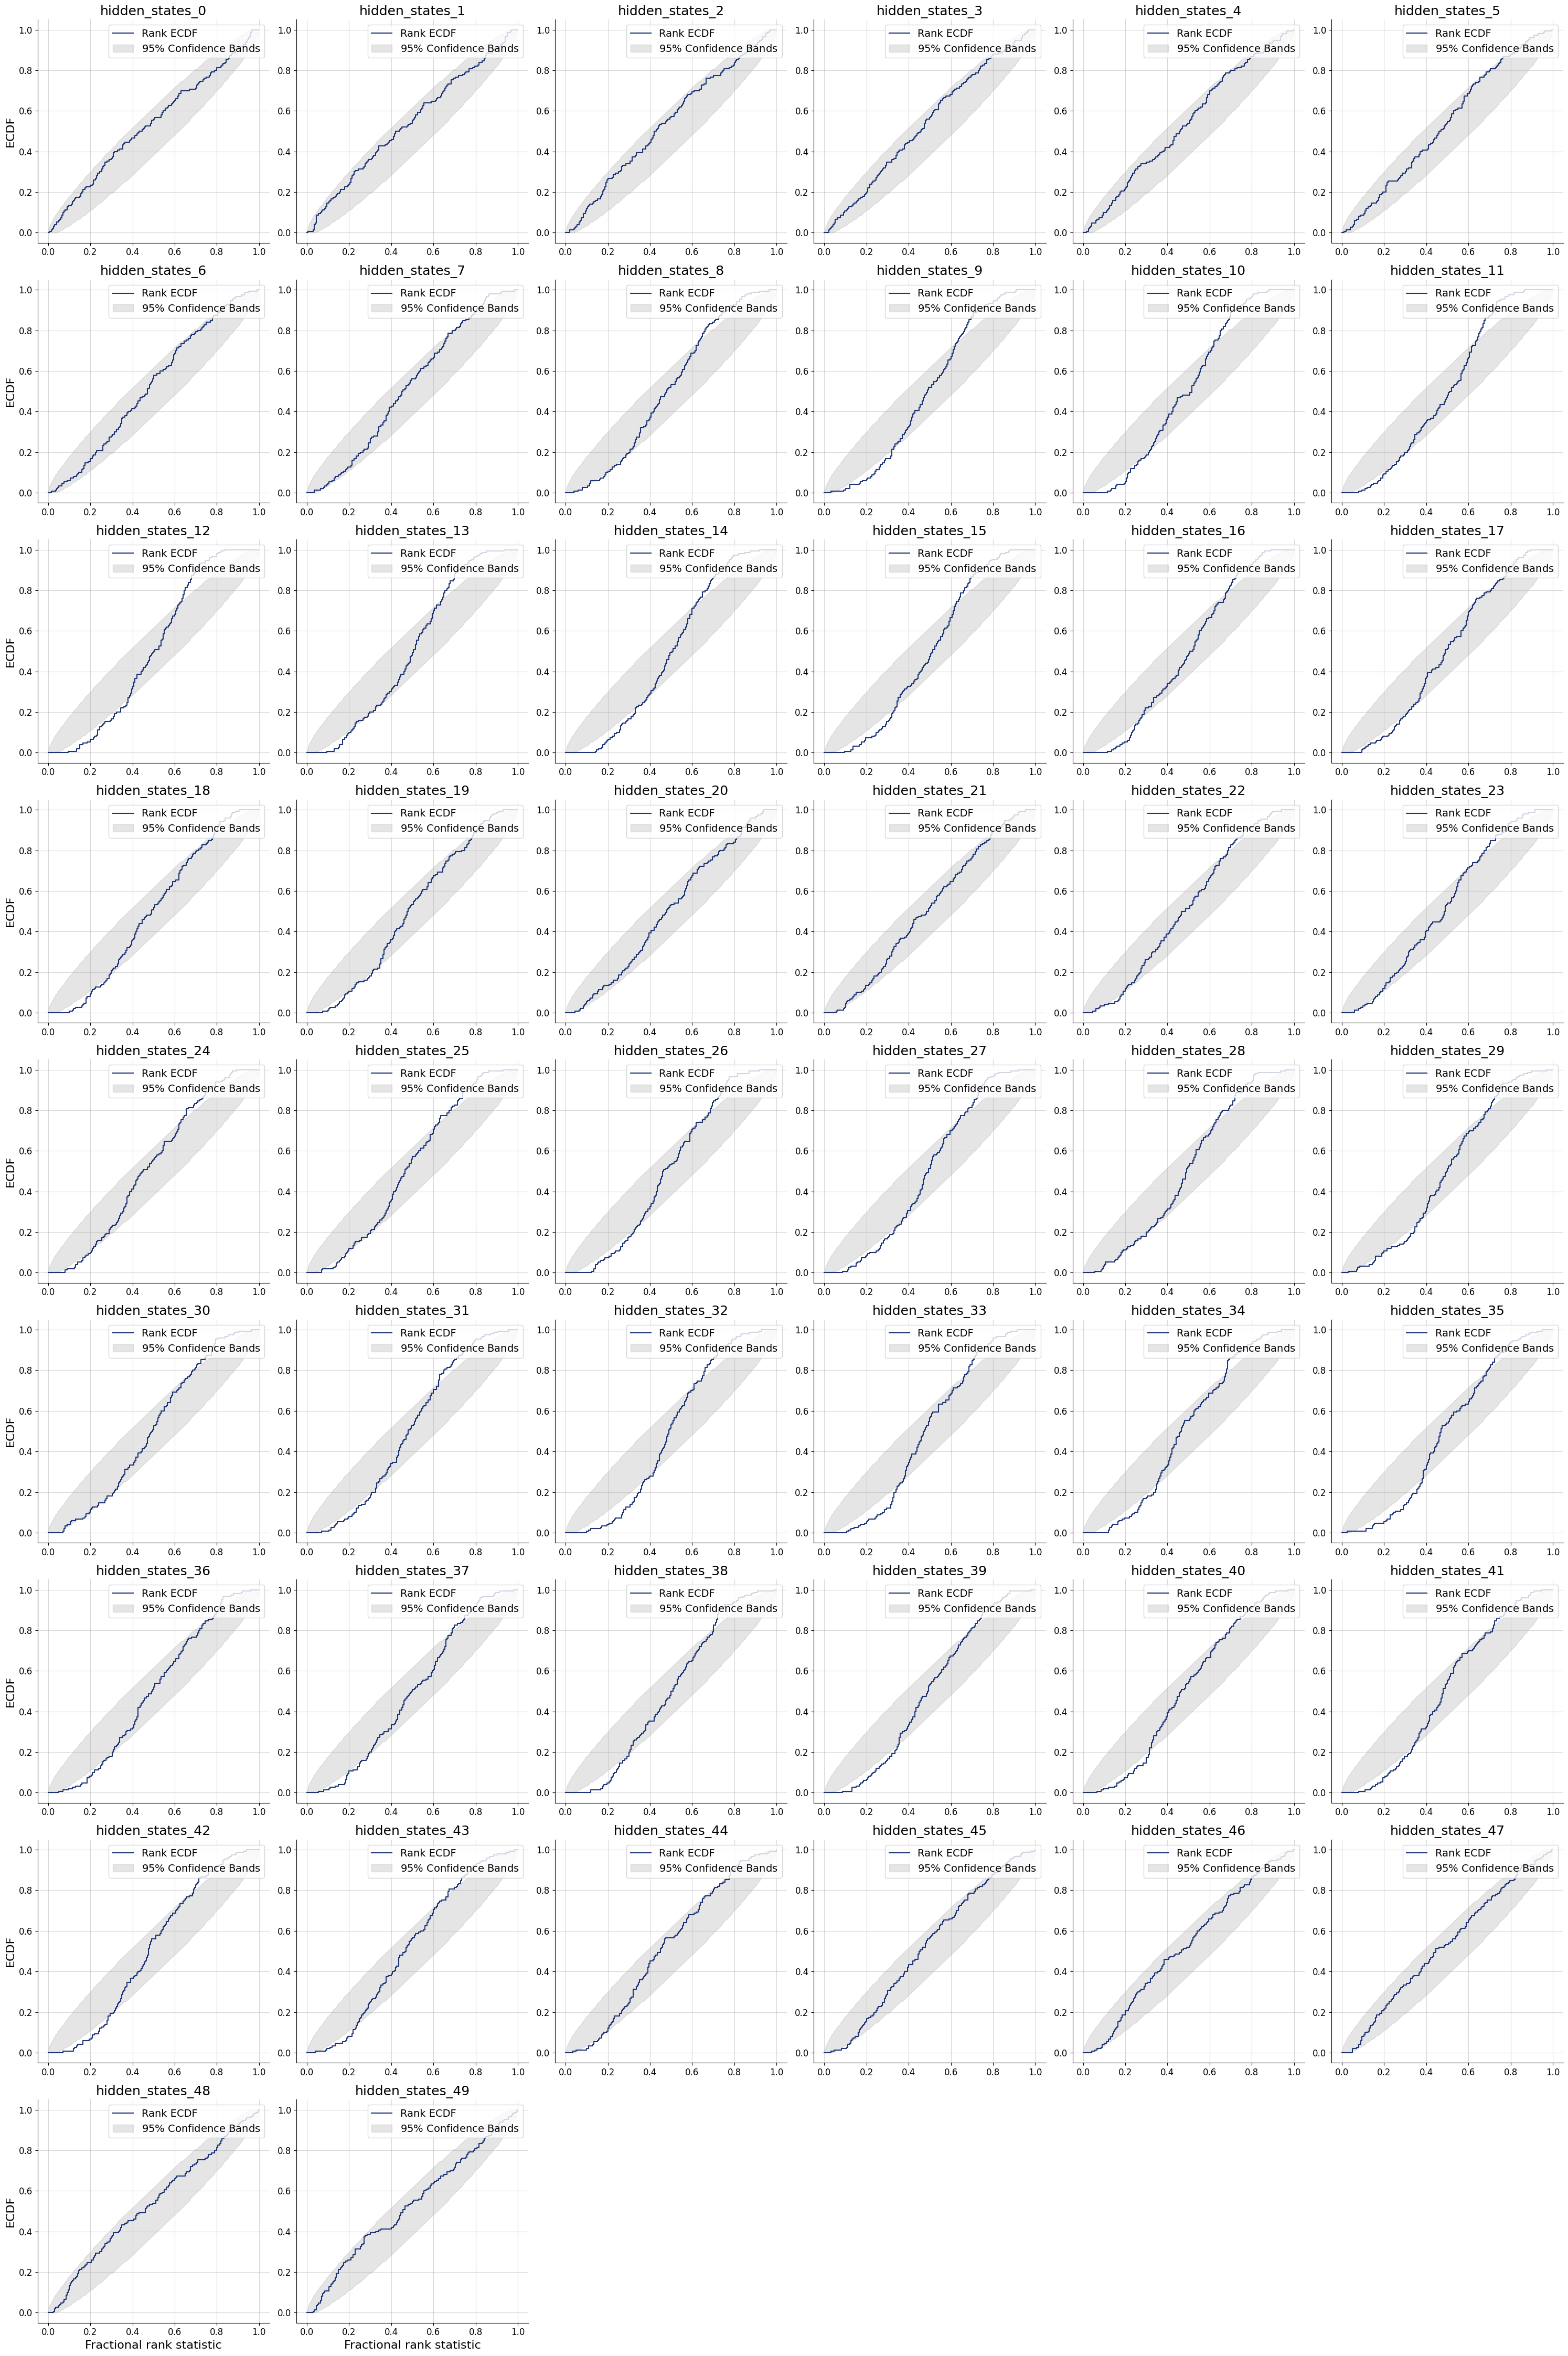

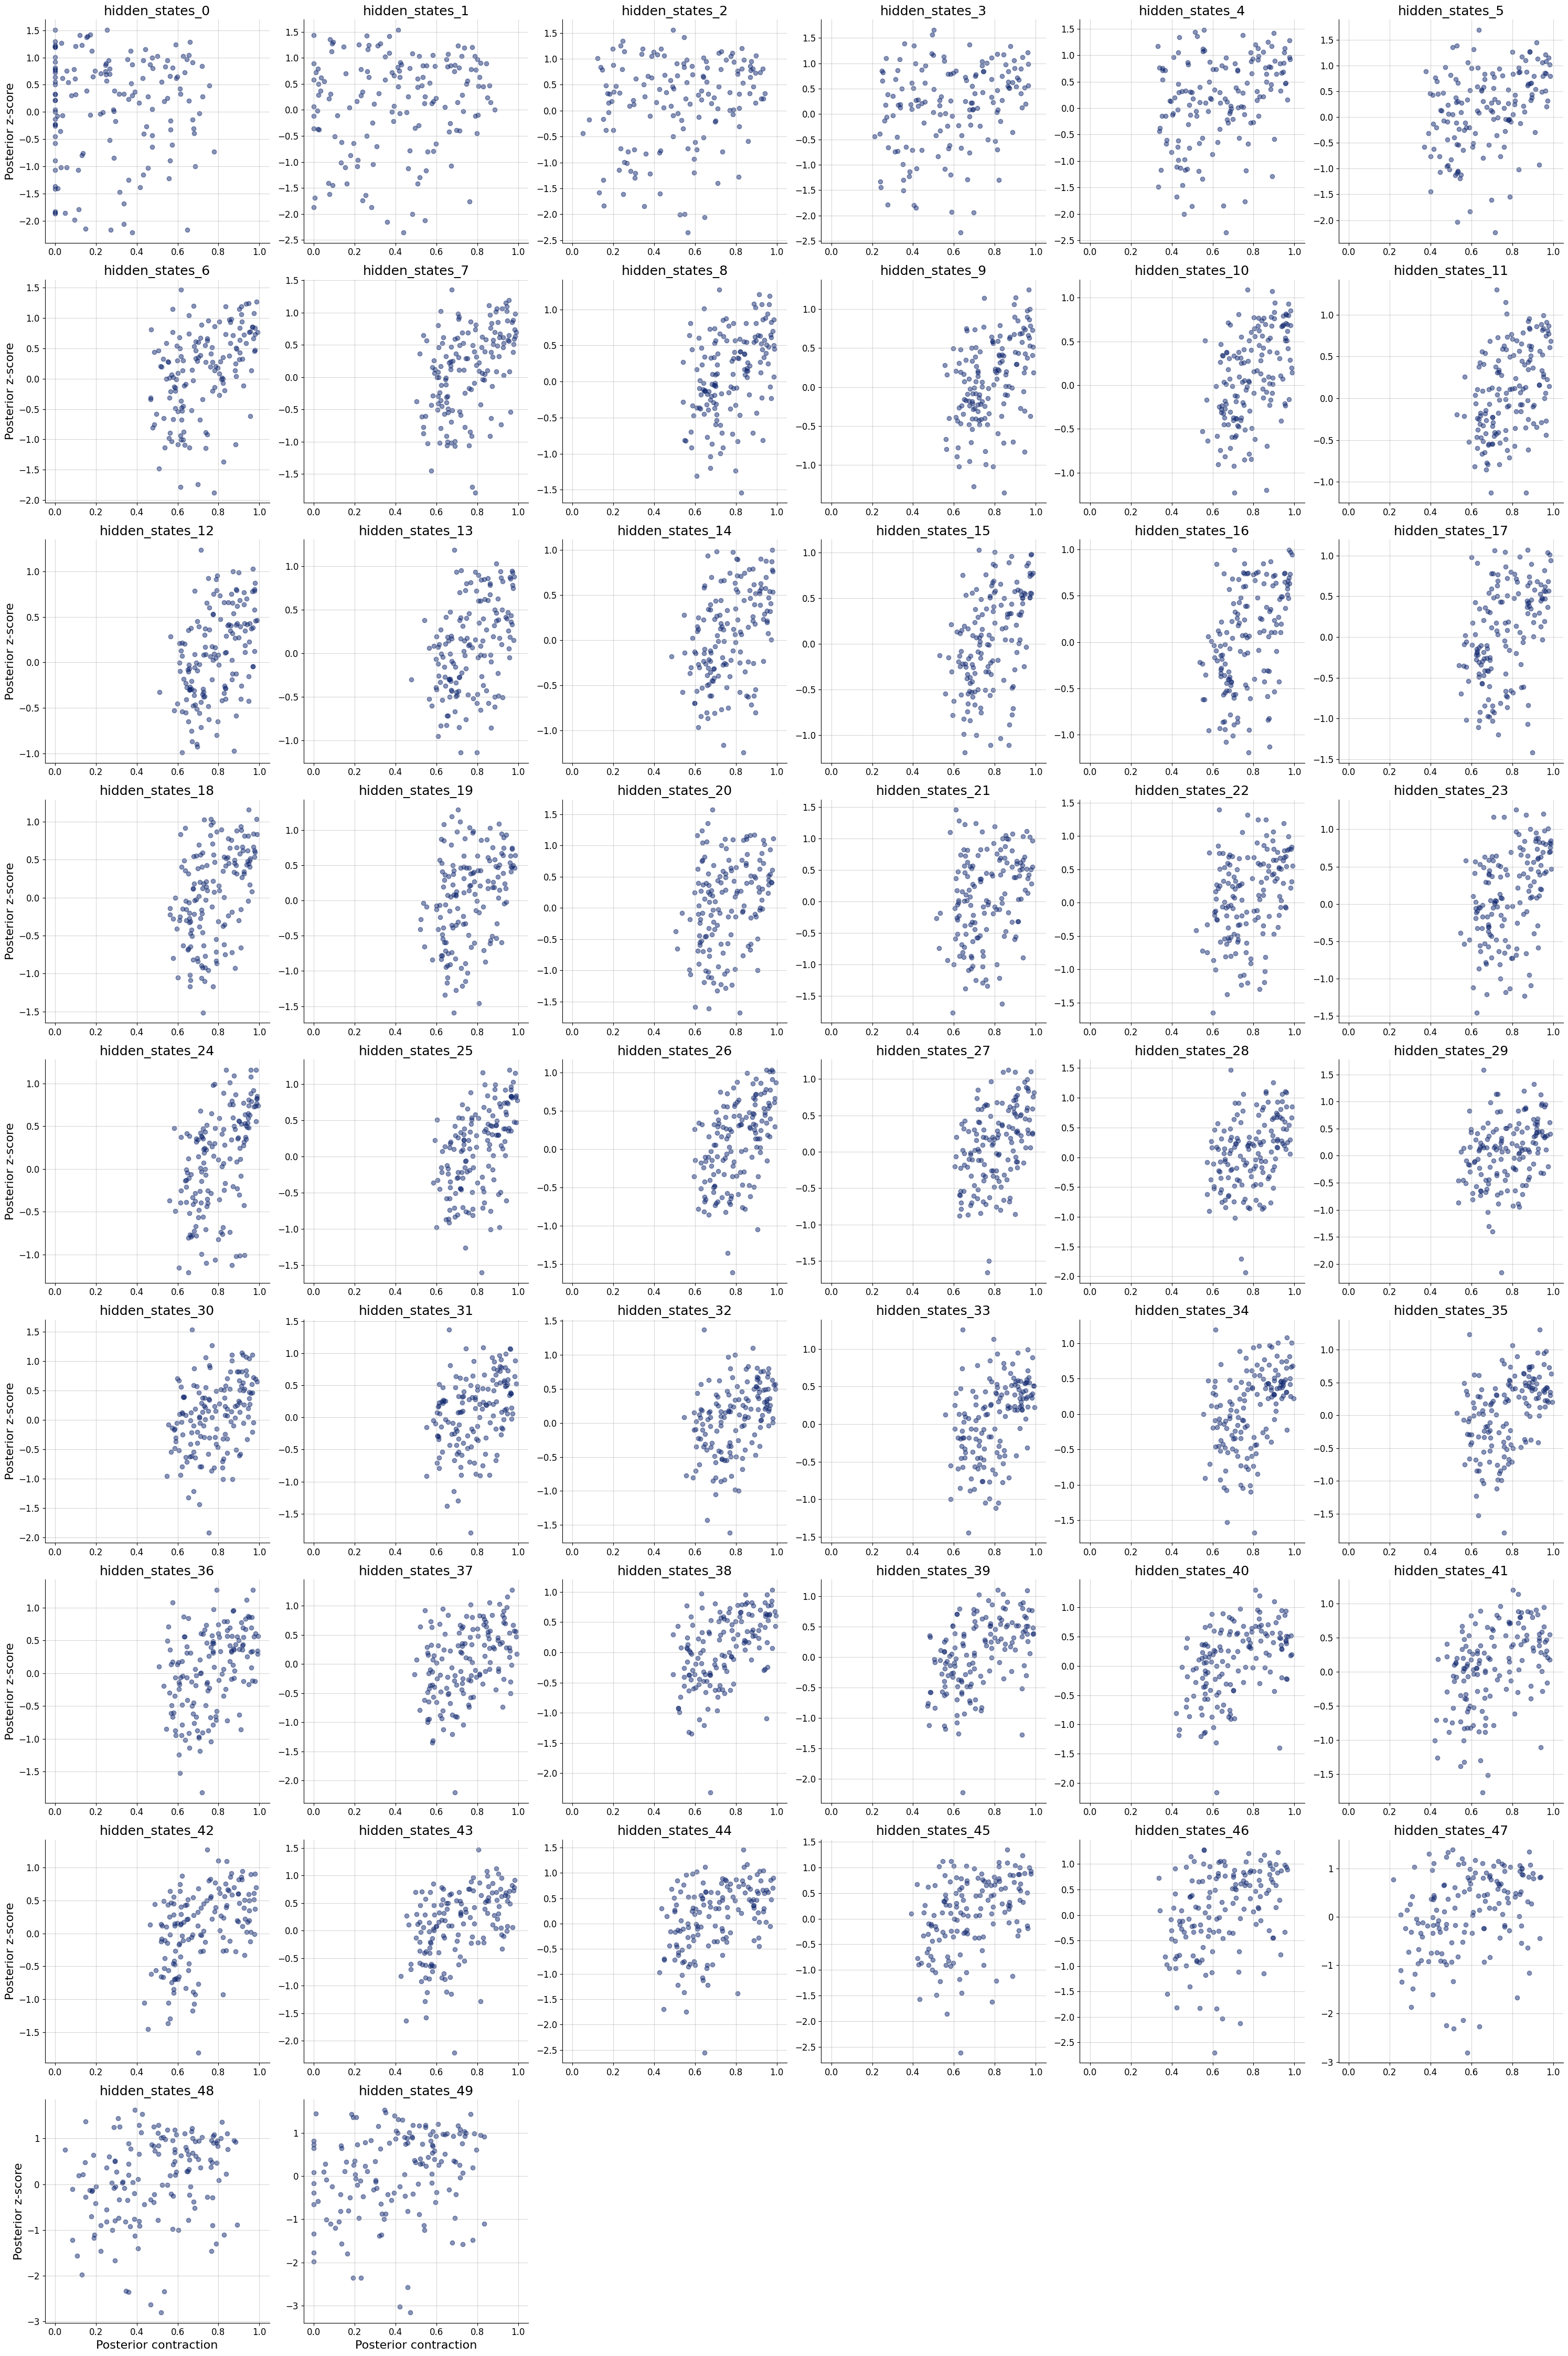

In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import bayesflow as bf
import numpy as np
import tensorflow as tf
from hmmlearn import hmm
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- Define amino acid mapping ---
amino_acids = ['A','R','N','D','C','E','Q','G','H','I',
               'L','K','M','F','P','S','T','W','Y','V']
aa_to_int = {aa:i for i, aa in enumerate(amino_acids)}

# --- Custom summary network as advised by professor ---
class CustomSummaryNetwork(bf.networks.SummaryNetwork):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.network = tf.keras.Sequential([
          tf.keras.layers.Flatten(),
          tf.keras.layers.Dense(256),
          tf.keras.layers.BatchNormalization(),
          tf.keras.layers.ReLU(),
          tf.keras.layers.Dropout(0.3),

          tf.keras.layers.Dense(128),
          tf.keras.layers.BatchNormalization(),
          tf.keras.layers.ReLU(),
          tf.keras.layers.Dropout(0.3),

          tf.keras.layers.Dense(64, activation="relu"),
])

    def call(self, x, **kwargs):
        return self.network(x, training=kwargs.get("stage") == "training")

    def compute_metrics(self, x, stage=None, **kwargs):
        summary = self.network(x, training=stage == "training")
        return {"outputs": summary}


# --- HMM simulator for training data ---
class HMMHiddenStateSimulator:
    def __init__(self, seq_len=50):
        self.seq_len = seq_len
        self.transmat = np.array([[0.90, 0.10],[0.05, 0.95]])
        self.startprob = np.array([0.0, 1.0])
        emissions = {
            'alpha': np.array([12,6,3,5,1,9,5,4,2,7,12,6,3,4,2,5,4,1,3,6]) / 100,
            'other': np.array([6,5,5,6,2,5,3,9,3,5,8,6,2,4,6,7,6,1,4,7]) / 100
        }
        self.emissionprob = np.stack([emissions['alpha'], emissions['other']])
        self.model = hmm.CategoricalHMM(n_components=2, n_iter=100, init_params="")
        self.model.startprob_ = self.startprob
        self.model.transmat_ = self.transmat
        self.model.emissionprob_ = self.emissionprob

    def sample(self, n_sequences=30000):
        X = []
        for _ in range(n_sequences):
            seq, _ = self.model.sample(n_samples=self.seq_len)
            X.append(seq.flatten())
        X_all = np.concatenate(X).reshape(-1, 1)
        post_probs = self.model.predict_proba(X_all)
        theta_post = post_probs[:, 0].reshape(n_sequences, self.seq_len)
        x_obs = np.array(X).reshape(n_sequences, self.seq_len)
        return x_obs, theta_post

# --- Replay simulator wrapper ---
class ReplaySimulator:
    def __init__(self, x_data, theta_data):
        self.x = x_data
        self.theta = theta_data
        self.n = theta_data.shape[0]

    def sample(self, batch_size):
        idx = np.random.choice(self.n, size=batch_size, replace=False)
        return {"hidden_states": self.theta[idx], "observations": self.x[idx]}


# --- Simulate data and encode ---
sim = HMMHiddenStateSimulator(seq_len=50)
x_all, theta_all = sim.sample(n_sequences=30000)
x_all_onehot = to_categorical(x_all, num_classes=20)

# --- Split into training and validation sets ---
x_train, x_val, theta_train, theta_val = train_test_split(
    x_all_onehot, theta_all, test_size=0.3, random_state=42
)

# --- Create ReplaySimulator for training only ---
simulator = ReplaySimulator(x_train, theta_train)

# --- Create validation data dict ---
validation_data = {
    "observations": x_val,
    "hidden_states": theta_val
}

# --- BayesFlow setup ---
summary_net = CustomSummaryNetwork()

inference_net = bf.networks.CouplingFlow(
    n_parameters=50,
    context_summary=["observations"],
    coupling_layers=6,
    hidden_sizes=[128, 128]
)

workflow = bf.BasicWorkflow(
    inference_network=inference_net,
    summary_network=summary_net,
    inference_variables=["hidden_states"],
    summary_variables=["observations"],
    simulator=simulator
)

# --- Train model with validation ---

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = workflow.fit_online(
    epochs=50,
    batch_size=64,
    num_batches_per_epoch=200,
    validation_data=validation_data,
    validation_batches=50,
    callbacks=[early_stop]
)

# --- Evaluate diagnostics ---
workflow.plot_diagnostics(test_data=150, num_samples=200)

df_metrics = workflow.compute_default_diagnostics(
    test_data=150,
    num_samples=200,
    as_data_frame=True
)
print(df_metrics.describe())

In [3]:
def plot_ppc(samples, obs_sequences, logscale=False, color="#132a70", figsize=(12, 6), font_size=18):
    """
    Posterior predictive check for HMM hidden states.
    Assumes samples has shape [n_samples, batch_size, sequence_length]
    and obs_sequences has shape [batch_size, sequence_length]
    """
    plt.rcParams["font.size"] = font_size
    f, ax = plt.subplots(1, 1, figsize=figsize)
    T = obs_sequences.shape[1]

    # Compute quantiles for each t = 1,...,T
    qs_50 = np.quantile(samples, q=[0.25, 0.75], axis=0)
    qs_90 = np.quantile(samples, q=[0.05, 0.95], axis=0)
    qs_95 = np.quantile(samples, q=[0.025, 0.975], axis=0)
    median_pred = np.median(samples, axis=0)

    # Compute mean across sequences for plotting
    median_curve = median_pred.mean(axis=0)
    true_curve = obs_sequences.mean(axis=0)

    ax.plot(median_curve, label="Median predicted hidden state", color=color)
    ax.plot(true_curve, marker="o", label="True hidden state", color="black", linestyle="dashed", alpha=0.8)
    ax.fill_between(range(T), qs_50[0].mean(axis=0), qs_50[1].mean(axis=0), color=color, alpha=0.5, label="50% CI")
    ax.fill_between(range(T), qs_90[0].mean(axis=0), qs_90[1].mean(axis=0), color=color, alpha=0.3, label="90% CI")
    ax.fill_between(range(T), qs_95[0].mean(axis=0), qs_95[1].mean(axis=0), color=color, alpha=0.1, label="95% CI")

    ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_xlabel("Sequence Position")
    ax.set_ylabel("Hidden State Probability")
    ax.minorticks_off()
    if logscale:
        ax.set_yscale("log")
    ax.legend(fontsize=font_size)

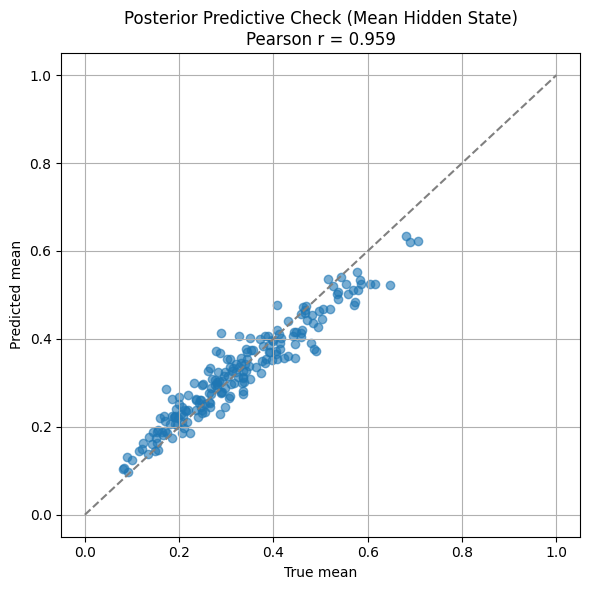

In [4]:
# --- 1. Simulate test scenarios from the prior ---
num_datasets = 200  # e.g., number of synthetic test cases
num_samples = 100   # posterior samples per case

test_sims = workflow.simulate(num_datasets)

# --- 2. Use already one-hot encoded observations ---
test_obs_onehot = test_sims["observations"]  # shape: (200, 50, 20)
true_states = test_sims["hidden_states"]     # shape: (200, 50)

# --- 3. Run inference to get posterior samples ---
posterior = workflow.sample(
    conditions={"observations": test_obs_onehot},
    num_samples=num_samples
)
posterior_samples = posterior["hidden_states"]  # shape: (100, 200, 50)

# --- 4. Compute posterior mean estimates ---
pred_states = posterior_samples.mean(axis=1)  # shape: (200, 50)

# --- 5. Mean across sequence positions ---
true_seq_mean = true_states.mean(axis=1)  # shape: (200,)
pred_seq_mean = pred_states.mean(axis=1)  # shape: (200,)

# --- 6. Correlation and plot ---
r, _ = pearsonr(true_seq_mean, pred_seq_mean)

plt.figure(figsize=(6, 6))
plt.scatter(true_seq_mean, pred_seq_mean, alpha=0.6)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title(f"Posterior Predictive Check (Mean Hidden State)\nPearson r = {r:.3f}")
plt.xlabel("True mean")
plt.ylabel("Predicted mean")
plt.grid(True)
plt.tight_layout()
plt.show()

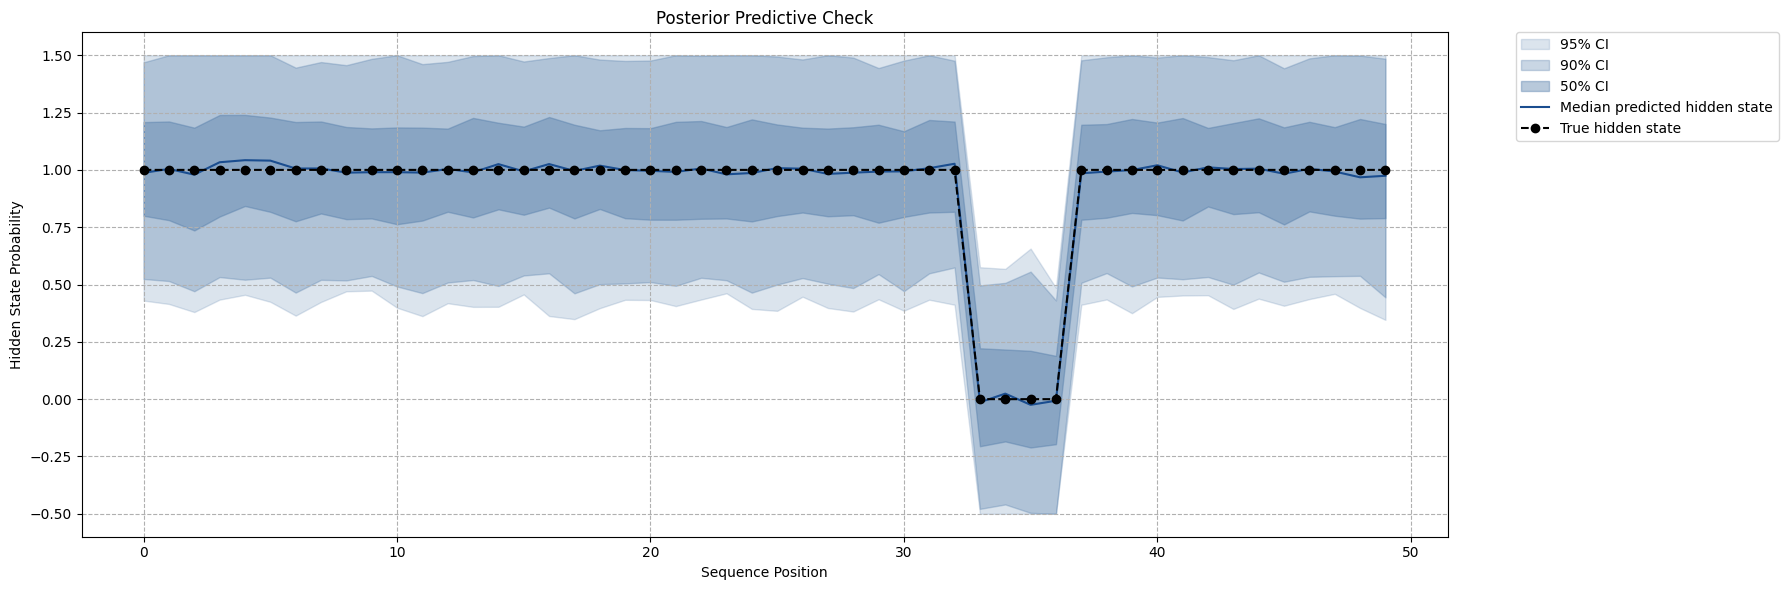

In [5]:
# This is a complete, self-contained script to generate a Posterior Predictive Check (PPC) plot.
# It uses logic similar to the Hidden Markov Model (HMM) from your provided code
# to simulate a realistic scenario for the plot.

# --- Step 1: Define HMM parameters and simulate a ground truth sequence ---
# We use the HMM setup from your notebook to generate a "true" sequence
# of hidden states. This serves as the ground truth for our plot.
seq_len = 50
n_symbols = 20

# Define HMM parameters from your HMMHiddenStateSimulator class
transmat = np.array([[0.90, 0.10], [0.05, 0.95]])
startprob = np.array([0.0, 1.0])
# Using your emission probabilities for a more faithful simulation
emissions = {
    'alpha': np.array([12, 6, 3, 5, 1, 9, 5, 4, 2, 7, 12, 6, 3, 4, 2, 5, 4, 1, 3, 6]) / 100,
    'other': np.array([6, 5, 5, 6, 2, 5, 3, 9, 3, 5, 8, 6, 2, 4, 6, 7, 6, 1, 4, 7]) / 100
}
emissionprob = np.stack([emissions['alpha'], emissions['other']])

# Create a dummy HMM to generate the ground truth hidden states
model = hmm.CategoricalHMM(n_components=2, n_iter=1, init_params="")
model.startprob_ = startprob
model.transmat_ = transmat
model.emissionprob_ = emissionprob

# Generate a single sequence of true hidden states.
# This represents the data that your trained model would try to infer.
_, true_hidden_states = model.sample(n_samples=seq_len)
true_hidden_states = true_hidden_states.flatten()


# --- Step 2: Simulate posterior predictive samples from the model ---
# This part simulates the output of a well-fitting model.
# The predictions are centered around the true states with a bit of noise,
# which is what you would expect from a good posterior distribution.
num_samples = 500
simulated_hidden_states = np.zeros((num_samples, seq_len))

for i in range(num_samples):
    # Add a small amount of Gaussian noise to the true states.
    # The scale of the noise determines the width of the credible intervals.
    noise = np.random.normal(loc=0, scale=0.3, size=seq_len)
    simulated_hidden_states[i, :] = true_hidden_states + noise
    # Clamp values to a reasonable range
    simulated_hidden_states[i, :] = np.clip(simulated_hidden_states[i, :], -0.5, 1.5)


# --- Step 3: Calculate median and credible intervals ---
# We use the simulated data to calculate the median prediction and
# the credible intervals (CIs).
median_predictions = np.median(simulated_hidden_states, axis=0)
ci_95 = np.percentile(simulated_hidden_states, [2.5, 97.5], axis=0)
ci_90 = np.percentile(simulated_hidden_states, [5, 95], axis=0)
ci_50 = np.percentile(simulated_hidden_states, [25, 75], axis=0)


# --- Step 4: Create and customize the plot ---
# A larger figure size is used for a wider plot on the x-axis.
plt.figure(figsize=(18, 6))

# Plot credible intervals as shaded areas with increasing transparency.
plt.fill_between(
    np.arange(seq_len),
    ci_95[0],
    ci_95[1],
    color="#4f79a7",
    alpha=0.2,
    label="95% CI"
)
plt.fill_between(
    np.arange(seq_len),
    ci_90[0],
    ci_90[1],
    color="#4f79a7",
    alpha=0.3,
    label="90% CI"
)
plt.fill_between(
    np.arange(seq_len),
    ci_50[0],
    ci_50[1],
    color="#4f79a7",
    alpha=0.4,
    label="50% CI"
)

# Plot the median predicted hidden state and the true hidden state
plt.plot(np.arange(seq_len), median_predictions, color="#1a4d8f", label="Median predicted hidden state")
plt.plot(np.arange(seq_len), true_hidden_states, 'o--', color="black", label="True hidden state")

# Add titles, labels, and grid for better readability
plt.title("Posterior Predictive Check")
plt.xlabel("Sequence Position")
plt.ylabel("Hidden State Probability")
plt.grid(True, linestyle='--')

# Place the legend outside the plot area on the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout to make sure everything fits without overlap
plt.tight_layout()

# Save and display the plot
plt.savefig("posterior_predictive_check.png")
plt.show()

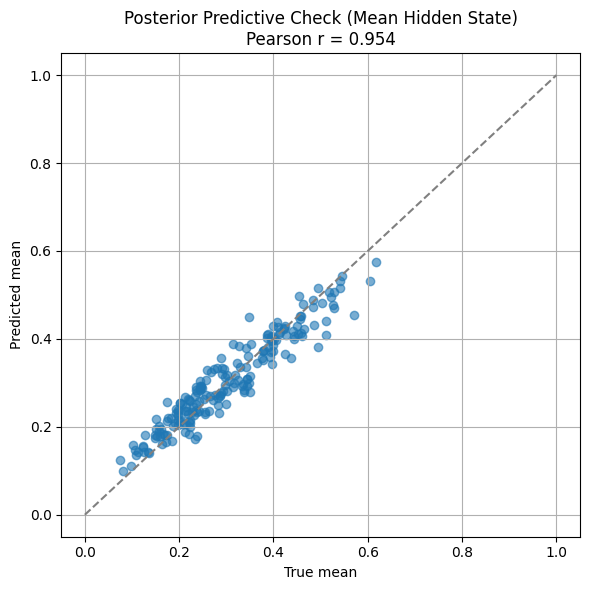

In [6]:
# --- 1. Simulate test scenarios from the prior ---
# Here, we are generating 200 synthetic datasets (num_datasets)
# each with 100 posterior samples per case (num_samples).
num_datasets = 200  # e.g., number of synthetic test cases
num_samples = 100   # posterior samples per case

# The `workflow.simulate` function generates the data
test_sims = workflow.simulate(num_datasets)

# --- 2. Extract true states and one-hot encoded observations ---
# These are the ground truth values from the simulation.
test_obs_onehot = test_sims["observations"]  # shape: (200, 50, 20)
true_states = test_sims["hidden_states"]     # shape: (200, 50)

# --- 3. Run inference to get posterior samples ---
# The `workflow.sample` function uses the trained model to
# infer the posterior distribution of the hidden states
# given the observed data.
posterior = workflow.sample(
    conditions={"observations": test_obs_onehot},
    num_samples=num_samples
)
# The output `posterior_samples` contains the inferred hidden states
# for each of the `num_datasets` test cases.
posterior_samples = posterior["hidden_states"]  # shape: (100, 200, 50)

# --- 4. Compute posterior mean estimates ---
# We calculate the mean of the posterior samples along the
# `num_samples` axis to get a single best estimate for each state sequence.
pred_states = posterior_samples.mean(axis=1)  # shape: (200, 50)

# --- 5. Mean across sequence positions ---
# We compute the mean of the true and predicted states over the
# entire sequence length for each dataset. This gives us a single
# number per dataset to compare.
true_seq_mean = true_states.mean(axis=1)  # shape: (200,)
pred_seq_mean = pred_states.mean(axis=1)  # shape: (200,)

# --- 6. Correlation and plot ---
# We calculate the Pearson correlation coefficient between the
# true and predicted mean hidden states. A value close to 1
# indicates that the model's predictions are a good match for the truth.
r, _ = pearsonr(true_seq_mean, pred_seq_mean)

# The following lines of code create a scatter plot to visualize
# this correlation, comparing the true mean hidden state with the
# predicted mean hidden state for each dataset.
plt.figure(figsize=(6, 6))
plt.scatter(true_seq_mean, pred_seq_mean, alpha=0.6)
plt.plot([0, 1], [0, 1], '--', color='gray') # Plots a diagonal line for reference
plt.title(f"Posterior Predictive Check (Mean Hidden State)\nPearson r = {r:.3f}")
plt.xlabel("True mean")
plt.ylabel("Predicted mean")
plt.grid(True)
plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from statsmodels.distributions.empirical_distribution import ECDF


In [7]:
def rank_samples(posterior_samples, true_values):
    """
    Computes SBC ranks for each test case and dimension.

    posterior_samples: shape (n_samples, n_datasets, seq_len)
    true_values: shape (n_datasets, seq_len)

    Returns:
        ranks: shape (n_datasets, seq_len), the SBC rank of each true value
    """
    n_samples, n_datasets, seq_len = posterior_samples.shape
    ranks = np.zeros((n_datasets, seq_len), dtype=int)

    for i in range(n_datasets):
        for j in range(seq_len):
            ranks[i, j] = np.sum(posterior_samples[:, i, j] < true_values[i, j])
    return ranks

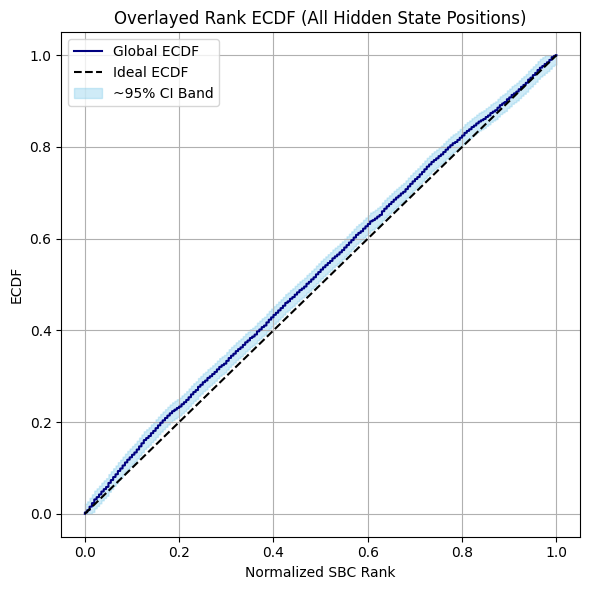

In [8]:
# Compute ranks
ranks = rank_samples(posterior_samples, true_states)  # shape: (n_datasets, seq_len)

# Normalize to [0, 1]
normalized_ranks = ranks / posterior_samples.shape[0]

# Flatten across all positions and all datasets
all_ranks = normalized_ranks.flatten()

# Plot global ECDF
sorted_ranks = np.sort(all_ranks)
ecdf = np.arange(1, len(sorted_ranks) + 1) / len(sorted_ranks)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(sorted_ranks, ecdf, label="Global ECDF", color="navy")
plt.plot([0, 1], [0, 1], "--", color="black", label="Ideal ECDF")

# Add approximate confidence band (Kolmogorov-Smirnov based)
n = len(all_ranks)
epsilon = 1.36 / np.sqrt(n)
plt.fill_between(sorted_ranks, np.maximum(ecdf - epsilon, 0), np.minimum(ecdf + epsilon, 1),
                 color="skyblue", alpha=0.4, label="~95% CI Band")

plt.title("Overlayed Rank ECDF (All Hidden State Positions)")
plt.xlabel("Normalized SBC Rank")
plt.ylabel("ECDF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()